# <center>Análisis exploratorio y limpieza de datos del Directorio de la Minería Mexicana.</center>

Se trabajó con información del Directorio de la Minería Mexicana del Servicio Geológico Mexicano con el objetivo de identificar patrones relacionados con minerales, ubicación geográfica y actividades mineras mediante técnicas de limpieza, transformación y análisis de datos.
## Objetivo del proyecto:
* Realizar procesos de limpieza, transformación y análisis exploratorio de datos utilizando Python y Pandas.
* Integrar SQLite para ejecutar consultas estructuradas y simular un entorno básico de análisis de datos basado en bases de datos relacionales.
* Identificar patrones, frecuencias y distribuciones relevantes dentro del dataset mediante consultas SQL y análisis exploratorio.
* Generar visualizaciones utilizando Matplotlib para facilitar la interpretación de resultados y comunicar hallazgos relevantes.
## Descripción:
El conjunto de datos contiene información relacionada con unidades mineras en México, incluyendo:
* El nombre de la unidad minera.
* Ciudad.
* Estado.
* Minerales explotados.
* Actividades realizadas.

El dataset presenta problemas típicos de calidad de datos:
* Valores múltiples en una sola celda.
* Diferencias de formato.
* Espacios en blanco.
* Inconsistencia entre mayúsculas y minúsculas.
  
## Preguntas iniciales para análisis:
* ¿Qué estados concentran más actividad minera?
* ¿Qué minerales aparecen con mayor frecuencia?
* ¿Qué actividades mineras son más comunes?

## Limpieza.

1. Como primer paso se importaron las librerias necesarias para la práctica.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

2. Después se leeyó el archivo cvs através de la libreria Pandas. Nota: Se tuvo que descargar el archivo directamente de la página, no se pudo extraer através de la libreria request.

In [3]:
file = "Metalicos_No_Metalicos_Minas.csv"
df = pd.read_csv(file,header=0)

In [4]:
#Visualización inicial del dataset para verificar la correcta carga de información
df.head(5)

,nombre,tipo_unidad,domicilio,asentamiento,ciudad,cp,estado,municipio,no_tel,responsable_puesto,pagina_web,correo_electronico,mineral,realiza,longitud_x,latitud_y,fecha_actualizacion
0,Agnico Eagle Mines Limited,Grupo,"Blvd. Luis Donaldo Colosio n.° 450, nivel 7. C...",Alameda,Hermosillo,83204,Sonora,Hermosillo,662 236 2220,"Amador Montaño Gustavo Ernesto, Director de de...",www.agnicoeagle.com,gustavo.amador@agnicoeagle.com / marco.galindo...,"Oro, plata","Exploración, explotación",-110.987361,29.093361,apr-25
1,"Altos Hornos de México, S.A.B. de C.V.",Grupo,Prol. Juárez s/n. Colonia La Loma,La Loma,Monclova,25770,Coahuila de Zaragoza,Monclova,866 649 3000,"Ancira Elizondo Alfonso, Director general",www.ahmsa.com,ventas@ahmsa.com,Fierro,Comercialización,-101.420389,26.886271,apr-25
2,"ArcelorMittal México, S.A. de C.V.",Grupo,Av. Lázaro Cárdenas n.° 2424. Colonia Residenc...,Residencial San Agustín Primer Sector,San Pedro Garza García,66260,Nuevo León,San Pedro Garza García,811 223 6700,"M. Cairo Víctor, Director ejecutivo",mexico.arcelormittal.com,victor.cairo@arcelormittal.com,Fierro,Fabricación,-100.333539,25.652099,apr-25
3,Argonaut Gold Inc.,Grupo,Blvd. Carlos Quintero Arce n.° 24 sur B. Colon...,Puerta Grande,Hermosillo,83247,Sonora,Hermosillo,662 264 8191,"Young Richard, Presidente CEO",www.argonautgold.com,richasrd.young@argonautgold.com,"Oro, plata",Explotación,-110.995361,29.143750,apr-25
4,Atsa Minerales,Grupo,Vicente Guerrero n.° 6. Colonia San Juan Ixhua...,San Juan Ixhuatepec,Tlalnepantla de Baz,54180,Estado de México,Tlalnepantla de Baz,559 454 0100,"Ricardi Ignacio, Gerente de Administración",atsaminerales.com/,ventas@atsaminerales.com,"Caolín, carbonato de calcio",Transformación de minerales,-99.104110,19.513111,oct-25


In [5]:
#Visualización tipos de datos y otroas caracteristicas del dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 579 entries, 0 to 578
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   nombre               579 non-null    object 
 1   tipo_unidad          579 non-null    object 
 2   domicilio            579 non-null    object 
 3   asentamiento         579 non-null    object 
 4   ciudad               579 non-null    object 
 5   cp                   579 non-null    int64  
 6   estado               579 non-null    object 
 7   municipio            579 non-null    object 
 8   no_tel               579 non-null    object 
 9   responsable_puesto   579 non-null    object 
 10  pagina_web           579 non-null    object 
 11  correo_electronico   579 non-null    object 
 12  mineral              579 non-null    object 
 13  realiza              579 non-null    object 
 14  longitud_x           579 non-null    float64
 15  latitud_y            579 non-null    flo

In [6]:
# Determinación cantidad de valores nulos.
df.isnull().sum()

nombre                 0
tipo_unidad            0
domicilio              0
asentamiento           0
ciudad                 0
cp                     0
estado                 0
municipio              0
no_tel                 0
responsable_puesto     0
pagina_web             0
correo_electronico     0
mineral                0
realiza                0
longitud_x             0
latitud_y              0
fecha_actualizacion    0
dtype: int64

In [7]:
# Detectección duplicados.
df.duplicated().sum()

np.int64(0)

### Hallazgos iniciales:
- No es necesario modificar los encabezados del dataseat, por lo que se mantienen con sus nombres originales.
- Las columnas como "mineral" y "realiza" contienen múltiples valores dentro de una celda. Esto podría dificultar el análisis, por lo que podría ser necesario separar estos valores en registros independientes.
- No existen duplicados.
- No hay celdas vacías.
### Variables principales para el análisis.
| Nombre del dato | Tipo de dato |
| :--- | :---: |
| nombre | TEXT |
| tipo_unidad | TEXT |
| estado | TEXT |
| mineral | TEXT |
| realiza | TEXT |

## Problemas detectados.
Durante la revisión del dataseat se detectó que la mayoría de las variables presentan una estructura consistente. Sin embargo, el problema principal problema identificado es la presencia de multiples registros dentro de una celda, lo cual puede dificultar el analisis. Para resolverlo se aplicaron procesos de normalización y transformación.

### Normalización y transformación.

Las columnas *"mineral"* y *"realiza"* presentan los problemas detectados. Primero que nada se convierte las celdas en string y luego en listas.
Después se realiza todas las combinaciones de las filas, através del comando **.explode()**.

In [8]:
df["mineral"] = df["mineral"].str.split(',')
df["realiza"] = df["realiza"].str.split(',')
df_normalizado = df.explode("mineral").explode("realiza")
df_normalizado.head(10)

,nombre,tipo_unidad,domicilio,asentamiento,ciudad,cp,estado,municipio,no_tel,responsable_puesto,pagina_web,correo_electronico,mineral,realiza,longitud_x,latitud_y,fecha_actualizacion
0,Agnico Eagle Mines Limited,Grupo,"Blvd. Luis Donaldo Colosio n.° 450, nivel 7. C...",Alameda,Hermosillo,83204,Sonora,Hermosillo,662 236 2220,"Amador Montaño Gustavo Ernesto, Director de de...",www.agnicoeagle.com,gustavo.amador@agnicoeagle.com / marco.galindo...,Oro,Exploración,-110.987361,29.093361,apr-25
0,Agnico Eagle Mines Limited,Grupo,"Blvd. Luis Donaldo Colosio n.° 450, nivel 7. C...",Alameda,Hermosillo,83204,Sonora,Hermosillo,662 236 2220,"Amador Montaño Gustavo Ernesto, Director de de...",www.agnicoeagle.com,gustavo.amador@agnicoeagle.com / marco.galindo...,Oro,explotación,-110.987361,29.093361,apr-25
0,Agnico Eagle Mines Limited,Grupo,"Blvd. Luis Donaldo Colosio n.° 450, nivel 7. C...",Alameda,Hermosillo,83204,Sonora,Hermosillo,662 236 2220,"Amador Montaño Gustavo Ernesto, Director de de...",www.agnicoeagle.com,gustavo.amador@agnicoeagle.com / marco.galindo...,plata,Exploración,-110.987361,29.093361,apr-25
0,Agnico Eagle Mines Limited,Grupo,"Blvd. Luis Donaldo Colosio n.° 450, nivel 7. C...",Alameda,Hermosillo,83204,Sonora,Hermosillo,662 236 2220,"Amador Montaño Gustavo Ernesto, Director de de...",www.agnicoeagle.com,gustavo.amador@agnicoeagle.com / marco.galindo...,plata,explotación,-110.987361,29.093361,apr-25
1,"Altos Hornos de México, S.A.B. de C.V.",Grupo,Prol. Juárez s/n. Colonia La Loma,La Loma,Monclova,25770,Coahuila de Zaragoza,Monclova,866 649 3000,"Ancira Elizondo Alfonso, Director general",www.ahmsa.com,ventas@ahmsa.com,Fierro,Comercialización,-101.420389,26.886271,apr-25
2,"ArcelorMittal México, S.A. de C.V.",Grupo,Av. Lázaro Cárdenas n.° 2424. Colonia Residenc...,Residencial San Agustín Primer Sector,San Pedro Garza García,66260,Nuevo León,San Pedro Garza García,811 223 6700,"M. Cairo Víctor, Director ejecutivo",mexico.arcelormittal.com,victor.cairo@arcelormittal.com,Fierro,Fabricación,-100.333539,25.652099,apr-25
3,Argonaut Gold Inc.,Grupo,Blvd. Carlos Quintero Arce n.° 24 sur B. Colon...,Puerta Grande,Hermosillo,83247,Sonora,Hermosillo,662 264 8191,"Young Richard, Presidente CEO",www.argonautgold.com,richasrd.young@argonautgold.com,Oro,Explotación,-110.995361,29.143750,apr-25
3,Argonaut Gold Inc.,Grupo,Blvd. Carlos Quintero Arce n.° 24 sur B. Colon...,Puerta Grande,Hermosillo,83247,Sonora,Hermosillo,662 264 8191,"Young Richard, Presidente CEO",www.argonautgold.com,richasrd.young@argonautgold.com,plata,Explotación,-110.995361,29.143750,apr-25
4,Atsa Minerales,Grupo,Vicente Guerrero n.° 6. Colonia San Juan Ixhua...,San Juan Ixhuatepec,Tlalnepantla de Baz,54180,Estado de México,Tlalnepantla de Baz,559 454 0100,"Ricardi Ignacio, Gerente de Administración",atsaminerales.com/,ventas@atsaminerales.com,Caolín,Transformación de minerales,-99.104110,19.513111,oct-25
4,Atsa Minerales,Grupo,Vicente Guerrero n.° 6. Colonia San Juan Ixhua...,San Juan Ixhuatepec,Tlalnepantla de Baz,54180,Estado de México,Tlalnepantla de Baz,559 454 0100,"Ricardi Ignacio, Gerente de Administración",atsaminerales.com/,ventas@atsaminerales.com,carbonato de calcio,Transformación de minerales,-99.104110,19.513111,oct-25


Aseguramos que no hay duplicados através de la función info.

In [9]:
df_normalizado = df_normalizado.reset_index(drop=True)

Después de la normalización las columnas "mineral" y "realiza" quedan con incosistencias entre mayúsculas y minúsculas. Si se aplica el método **.lower()** a estas columnas, se corrige este problema y el análsis puede ser más sencillo. Otra correción a realizar sería el espacio que existe en las celdas, con el método **.strip()**.

In [10]:
df_normalizado['mineral'] = df_normalizado['mineral'].str.strip().str.lower()
df_normalizado['realiza'] = df_normalizado['realiza'].str.strip().str.lower()

In [11]:
#Se delimita la tabla de datos a las columnas que interesan analizar.
columnas_interes = ["nombre","tipo_unidad","estado","mineral","realiza"]

In [12]:
df_1 = df_normalizado[columnas_interes]
df_1.head(5)

,nombre,tipo_unidad,estado,mineral,realiza
0,Agnico Eagle Mines Limited,Grupo,Sonora,oro,exploración
1,Agnico Eagle Mines Limited,Grupo,Sonora,oro,explotación
2,Agnico Eagle Mines Limited,Grupo,Sonora,plata,exploración
3,Agnico Eagle Mines Limited,Grupo,Sonora,plata,explotación
4,"Altos Hornos de México, S.A.B. de C.V.",Grupo,Coahuila de Zaragoza,fierro,comercialización


Se contestan las preguntas iniciales através de SQL. Para eso se extrae la librería de SQLlite.

In [13]:
!pip install ipython-sql
!pip install seaborn
import seaborn as sns
%load_ext sql

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


In [14]:
import csv, sqlite3
con = sqlite3.connect("mina.db")
cur = con.cursor()

In [15]:
#Ademas se carga el modulo SQL magic.
%sql sqlite:///mina.db

In [16]:
#Se establece una conección entre SQL magic y la base de datos "mina.db"
df_1.to_sql("minas", con, if_exists='replace', index=False, method="multi")


2854

In [17]:

# Instalar librerías 'ipython-sql' y 'prettytable' usando pip
!pip install ipython-sql prettytable

# Importa la biblioteca 'prettytable', que se utiliza para mostrar datos en una tabla formateada.
import prettytable

# Establezca el formato de visualización predeterminado para prettytable en 'DEFAULT' (es decir, un formato de tabla simple).
prettytable.DEFAULT = 'DEFAULT'

Defaulting to user installation because normal site-packages is not writeable


## Análisis Exploratorio.

Primero se detectan los minerales presentes en el dataseat, para identificar aquellos que son metales y no metales.

In [18]:
%%sql
DROP VIEW IF EXISTS metal_nometal;

 * sqlite:///mina.db
Done.


[]

In [19]:
%%sql

CREATE VIEW IF NOT EXISTS metal_nometal AS

SELECT DISTINCT 
    mineral,

    CASE
        
        -- Minerales metalicos
        WHEN mineral LIKE '%oro%'
          OR mineral LIKE '%plata%'
          OR mineral LIKE '%cobre%'
          OR mineral LIKE '%zinc%'
          OR mineral LIKE '%plomo%'
          OR mineral LIKE '%molibdeno%'
          OR mineral LIKE '%litio%'
          OR mineral LIKE '%cobalto%'
          OR mineral LIKE '%manganeso%'
          OR mineral LIKE '%hierro%'
          OR mineral LIKE '%fierro%'
          OR mineral LIKE '%acero%'
          OR mineral LIKE '%ferromanganeso%'
        
        THEN 'metálico'

        
        -- Productos industriales transformados
        WHEN mineral LIKE '%cemento%'
          OR mineral LIKE '%concreto%'
          OR mineral LIKE '%block%'
          OR mineral LIKE '%losetas%'
          OR mineral LIKE '%cal hidratada%'
          OR mineral LIKE '%cal viva%'
        
        THEN 'industrial transformado'


        -- Categorías ambiguas o generales
        WHEN mineral LIKE '%sulfuro%'
          OR mineral LIKE '%sulfato%'
        
        THEN 'indeterminado'


        -- Todo lo demás
        ELSE 'no metálico'

    END AS tipo_mineral

FROM minas;

 * sqlite:///mina.db
Done.


[]

In [20]:
%%sql
SELECT * FROM metal_nometal
ORDER BY tipo_mineral;

 * sqlite:///mina.db
Done.


mineral,tipo_mineral
sulfato de sodio,indeterminado
sulfato,indeterminado
sulfuros,indeterminado
sulfato de magnesio,indeterminado
cemento,industrial transformado
concreto,industrial transformado
cal hidratada,industrial transformado
block,industrial transformado
concreto premezclado,industrial transformado
cemento blanco,industrial transformado


In [21]:
%%sql
SELECT tipo_mineral, COUNT(*)
FROM metal_nometal
GROUP BY tipo_mineral;

 * sqlite:///mina.db
Done.


tipo_mineral,COUNT(*)
indeterminado,4
industrial transformado,9
metálico,31
no metálico,45


Desde aquí se puede ver algo muy interesante, se puede generar una visualización donde se podría ver la clasificación de los minerales (metalicos, no metalicos, indeterminado e industrial transformado). Sin embargo, al observar esta nueva tabla formada se observa que los materiales metálicos están presentes en forma de minerales primarios y procesados, esto se puede ver a través de la existencia de hierro y fierro, que son dos formas que existe el metal hierro. Apartir de esto se pueden realizar algunas preguntas:
* ¿Que paises concentran mayor actividad extractiva?
* ¿Existe una relación entre tipo de unidad minera y tipo de mineral reportado?
* ¿Que estados muestran mayor divesificación minera?

Nivel de procesamiento.

In [22]:
%%sql
CREATE VIEW IF NOT EXISTS nivel_procesamiento AS

SELECT DISTINCT
    mineral,
    tipo_mineral,

    CASE
        WHEN mineral LIKE '%concentrado%' THEN 'concentrado'
        WHEN mineral LIKE '%refinado%' THEN 'refinado'
        WHEN mineral LIKE '%catódico%' THEN 'refinado'
        WHEN mineral LIKE '%afinado%' THEN 'refinado'
        WHEN mineral LIKE '%acero%' THEN 'transformado'
        ELSE 'primario'
    END AS nivel_procesamiento

FROM metal_nometal

WHERE tipo_mineral = 'metálico';
    

 * sqlite:///mina.db
Done.


[]

In [23]:
%%sql
SELECT mineral, tipo_mineral, nivel_procesamiento
FROM nivel_procesamiento;

 * sqlite:///mina.db
Done.


mineral,tipo_mineral,nivel_procesamiento
oro,metálico,primario
plata,metálico,primario
fierro,metálico,primario
cobre,metálico,primario
plomo,metálico,primario
zinc,metálico,primario
ferromanganeso alto y medio carbón,metálico,primario
molibdeno,metálico,primario
oro refinado,metálico,refinado
plata refinada,metálico,primario


2. Nivel de procesamiento por estado.

In [24]:
%%sql
SELECT m.estado, n.nivel_procesamiento, COUNT(*) AS Total
FROM minas m
JOIN nivel_procesamiento n
ON m.mineral=n.mineral
GROUP BY m.estado, n.nivel_procesamiento
ORDER BY m.estado, COUNT(*) Desc;


 * sqlite:///mina.db
Done.


estado,nivel_procesamiento,Total
Aguascalientes,primario,21
Aguascalientes,concentrado,4
Baja California,primario,12
Baja California Sur,primario,3
Chihuahua,primario,83
Chihuahua,refinado,2
Ciudad de México,primario,82
Ciudad de México,refinado,7
Ciudad de México,concentrado,6
Coahuila de Zaragoza,primario,86


Vale la pena revisar cuantas actividades realizan en total las empresas para evaluar si es necesaria una segmentación por tipo de actividad.

In [25]:
%%sql
SELECT DISTINCT realiza
FROM minas
GROUP BY realiza;

 * sqlite:///mina.db
Done.


realiza
beneficio (refinamiento)
calcinación
clasificación
comercialización
compra
concentración
corte
cribado
desarrollo minero
distribución de material de construcción


Son ~30 actividades, por lo tanto, es necesaria una segmentación para interpretar de mejor manera las gráficas que se van a generar. Por otra parte, también se observa que las actividades tienen una relación, por ejemplo, una actividad como exploración y extracción podrían ser clasificadas como categorías extractivas. Para eso se va a generar otra tabla.

In [27]:
%%sql
DROP VIEW IF EXISTS actividad_segmentada;

 * sqlite:///mina.db
Done.


[]

In [28]:
%%sql
CREATE VIEW actividad_segmentada AS
SELECT DISTINCT
    realiza,

    CASE
        WHEN realiza IN (
            'exploración',
            'extracción',
            'explotación',
            'desarrollo minero'
        ) THEN 'extractiva'

        WHEN realiza IN (
            'molienda',
            'flotación',
            'lixiviación',
            'concentración',
            'trituración de materiales',
            'cribado',
            'clasificación',
            'secado'
        ) THEN 'procesamiento'

        WHEN realiza IN (
            'beneficio (refinamiento)',
            'hidrometalurgia',
            'calcinación'
        ) THEN 'refinamiento'

        WHEN realiza IN (
            'comercialización',
            'compra',
            'distribución de material de construcción'
        ) THEN 'comercial'

        WHEN realiza IN (
            'fabricación',
            'transformación de minerales',
            'transformación (mecánica o química)'
        ) THEN 'industrial'

        ELSE 'otros'

    END AS categoria_actividad
FROM minas;

 * sqlite:///mina.db
Done.


[]

In [30]:
%%sql
SELECT m.tipo_unidad, a.categoria_actividad, COUNT(*) AS Total
FROM minas m
Join actividad_segmentada a
ON m.realiza = a.realiza
GROUP BY m.tipo_unidad, a.categoria_actividad
ORDER BY m.tipo_unidad, a.categoria_actividad;

 * sqlite:///mina.db
Done.


tipo_unidad,categoria_actividad,Total
Empresa,comercial,326
Empresa,extractiva,748
Empresa,industrial,32
Empresa,otros,2
Grupo,comercial,87
Grupo,extractiva,69
Grupo,industrial,18
Mina,comercial,39
Mina,extractiva,654
Mina,industrial,1


In [31]:
%%sql

WITH mineral_realiza AS (
    SELECT 
        n.nivel_procesamiento,
        m.realiza,
        COUNT(*) AS total
    FROM minas m
    JOIN nivel_procesamiento n
        ON n.mineral = m.mineral
    GROUP BY 
        n.nivel_procesamiento,
        m.realiza
)

SELECT 
    mr.nivel_procesamiento,
    a.categoria_actividad,
    SUM(mr.total) AS Total

FROM mineral_realiza mr

JOIN actividad_segmentada a
    ON mr.realiza = a.realiza

GROUP BY 
    mr.nivel_procesamiento,
    a.categoria_actividad

ORDER BY 
    mr.nivel_procesamiento,
    Total DESC;


 * sqlite:///mina.db
Done.


nivel_procesamiento,categoria_actividad,Total
concentrado,procesamiento,35
concentrado,extractiva,22
concentrado,comercial,3
primario,extractiva,1257
primario,procesamiento,387
primario,comercial,241
primario,otros,41
primario,refinamiento,40
primario,industrial,8
refinado,extractiva,7


In [32]:
%%sql
SELECT m.tipo_unidad, n.nivel_procesamiento, COUNT(*) AS Total
FROM minas m
JOIN nivel_procesamiento n
ON m.mineral=n.mineral
GROUP BY m.tipo_unidad, n.nivel_procesamiento
ORDER BY m.tipo_unidad, COUNT(*) Desc;

 * sqlite:///mina.db
Done.


tipo_unidad,nivel_procesamiento,Total
Empresa,primario,730
Empresa,concentrado,8
Empresa,refinado,3
Grupo,primario,102
Grupo,refinado,7
Grupo,transformado,3
Mina,primario,617
Mina,concentrado,14
Mina,refinado,1
Planta,primario,525


In [33]:
%%sql
WITH estado_realiza AS (
    SELECT 
        m.estado,
        m.realiza,
        COUNT(*) AS Total
    FROM minas m
    JOIN nivel_procesamiento n
        ON m.mineral = n.mineral
    GROUP BY 
        m.estado,
        m.realiza
)

SELECT 
    er.estado,
    a.categoria_actividad,
    SUM(er.Total) AS Total
FROM estado_realiza er


JOIN actividad_segmentada a
    ON er.realiza = a.realiza

WHERE categoria_actividad = "extractiva" 
GROUP BY 
    er.estado,
    a.categoria_actividad

ORDER BY
    Total DESC;


 * sqlite:///mina.db
Done.


estado,categoria_actividad,Total
Durango,extractiva,666
Sonora,extractiva,164
Chihuahua,extractiva,77
Ciudad de México,extractiva,71
Coahuila de Zaragoza,extractiva,61
Zacatecas,extractiva,50
Guerrero,extractiva,38
Hidalgo,extractiva,37
Guanajuato,extractiva,31
San Luis Potosí,extractiva,28


In [34]:
query = """
WITH estado_realiza AS (

    SELECT 
        m.estado,
        m.realiza,
        COUNT(*) AS Total

    FROM minas m

    JOIN nivel_procesamiento n
        ON m.mineral = n.mineral

    GROUP BY 
        m.estado,
        m.realiza
)

SELECT 
    er.estado,
    a.categoria_actividad,
    SUM(er.Total) AS Total

FROM estado_realiza er

JOIN actividad_segmentada a
    ON er.realiza = a.realiza

GROUP BY 
    er.estado,
    a.categoria_actividad

ORDER BY 
    er.estado,
    Total DESC;
"""

df_1 = pd.read_sql_query(query, con)



In [35]:
pivot = df_1.pivot_table(
    index='estado',
    columns='categoria_actividad',
    values='Total',
    fill_value=0
)

<Axes: xlabel='categoria_actividad', ylabel='estado'>

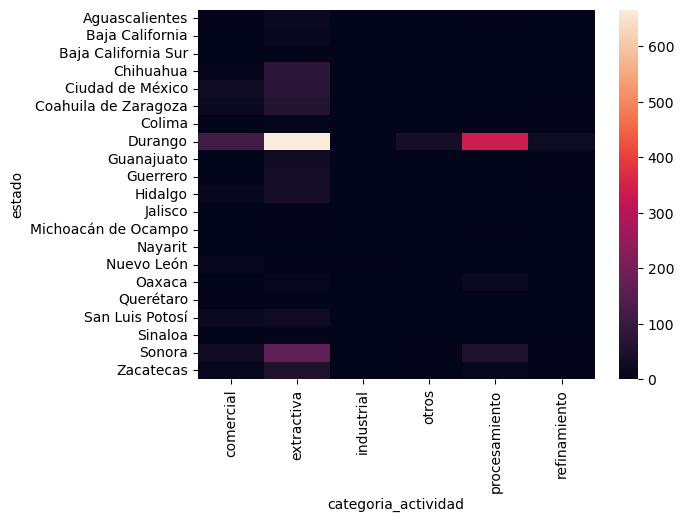

In [36]:
sns.heatmap(pivot)

In [37]:
pivot_norm = pivot.div(pivot.sum(axis=1), axis=0)

### Observación:
Este heatmap corresponde a un análisis exploratorio inicial. Debido al proceso explode aplicado a las columnas *"mineral"* y *"realiza"*, por lo que, el dataset experimento un incremento significativo en su granularidad, generando sobreconteos.
Aunque la clasificación de actividades había sido implementada, el modelo requería un rediseño para evitar interpretaciones distorsionadas.